# SEIRD-МОДЕЛЬ ДИНАМИКИ РАСПРОСТРАНЕНИЯ ВИРУСНЫХ ИНФЕКЦИЙ С УЧЕТОМ ВОЗНИКНОВЕНИЯ НОВЫХ ШТАММОВ

**Андреева Софья Владимировна НПИбд-01-23**

## Введение

Детерминистские математические модели эпидемий заболеваний позволяют изучать макроскопические явления распространения этих эпидемий в человеческом обществе. Однозначность, наглядность и простота этих моделей делают их привлекательными для анализа и позволяют получить информацию для управления протеканием эпидемии.

При создании таких моделей делается ряд упрощений: развитие эпидемии изучается в однородной непрерывно и равномерно перемешивающейся большой группе, что позволяет рассматривать общие процессы распространения эпидемии в упрощенной форме. Для успешной борьбы с эпидемиями заразных заболеваний недостаточно одних только профилактических мероприятий или лекарственного лечения, необходимо также учитывать, что существуют эпидемиологические проблемы, касающиеся распространения болезни в целом.

В 1927 г. в своей работе W. O. Kermack и A. G. MacKendrick создали и исследовали модель, представляющую собой систему дифференциальных уравнений с начальными условиями, которую называют классической SIR-моделью. Развитием SIR-модели являются также SEIR- (Exposed – латентные), MSEIR-модели (Maternally derived immunity – наделенные иммунитетом от рождения).

При изучении заболевания COVID-19, вызываемого вирусом SARS-CoV-2, предлагаются к рассмотрению SIRD-модели (Dead – умершие) и SEIRD-модели. Рассматриваемая в данной работе SEIRD-модель отличается тем, что учитывает способность инфицированных индивидуумов заражать восприимчивых индивидуумов в латентном (инкубационном) периоде.

In [5]:

# SEIRD-МОДЕЛЬ ДИНАМИКИ РАСПРОСТРАНЕНИЯ COVID-19 В МОСКВЕ
# Анализ данных с 16 марта 2020 по 18 марта 2025

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import minimize
from scipy.signal import find_peaks
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Настройка графиков
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

# Загрузка данных
df = pd.read_csv('covidmsk.csv')

# Преобразование дат и сортировка от старых к новым
df['Дата'] = pd.to_datetime(df['Дата'], format='%d/%m/%y')
df = df.sort_values('Дата').reset_index(drop=True)

# Очистка данных: замена "—" и "%" на числовые значения
df['Летальность'] = df['Летальность'].astype(str).str.replace('%', '').str.replace('—', '0')
df['Летальность'] = pd.to_numeric(df['Летальность'], errors='coerce').fillna(0)

# Преобразование числовых столбцов
for col in ['Заражений всего', 'Умерло всего', 'Выздоровело всего', 'Болеющих']:
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0).astype(float)


print("АНАЛИЗ ДАННЫХ ПО COVID-19 В Г. МОСКВЕ")

print(f"Период наблюдения: {df['Дата'].min().strftime('%d.%m.%Y')} - {df['Дата'].max().strftime('%d.%m.%Y')}")
print(f"Всего записей: {len(df)} дней")
print(f"Всего зараженных: {int(df['Заражений всего'].iloc[-1]):,} чел.")
print(f"Всего умерших: {int(df['Умерло всего'].iloc[-1]):,} чел.")
print(f"Летальность: {df['Умерло всего'].iloc[-1]/df['Заражений всего'].iloc[-1]*100:.2f}%")
print("\nПервые 5 записей данных:")
print(df.head())
print("\nПоследние 5 записей данных:")
print(df.tail())

АНАЛИЗ ДАННЫХ ПО COVID-19 В Г. МОСКВЕ
Период наблюдения: 16.03.2020 - 18.03.2025
Всего записей: 1253 дней
Всего зараженных: 3,885,719 чел.
Всего умерших: 50,067 чел.
Летальность: 1.29%

Первые 5 записей данных:
        Дата  Заражений всего  Умерло всего  Летальность  Выздоровело всего  \
0 2020-03-16             54.0           0.0          0.0                1.0   
1 2020-03-17             55.0           0.0          0.0                1.0   
2 2020-03-18             86.0           0.0          0.0                1.0   
3 2020-03-19             98.0           0.0          0.0                1.0   
4 2020-03-20            131.0           0.0          0.0                1.0   

   Болеющих  
0      53.0  
1      54.0  
2      85.0  
3      97.0  
4     130.0  

Последние 5 записей данных:
           Дата  Заражений всего  Умерло всего  Летальность  \
1248 2025-02-18        3882231.0       50055.0          0.0   
1249 2025-02-25        3883227.0       50056.0          0.0   
1250 2025-03

In [6]:
# Создание временной шкалы в днях от начала
df['day'] = range(1, len(df) + 1)

# Расчет прироста зараженных (новые случаи за период)
df['new_cases'] = df['Заражений всего'].diff().fillna(df['Заражений всего'].iloc[0])
# Расчет прироста умерших
df['new_deaths'] = df['Умерло всего'].diff().fillna(df['Умерло всего'].iloc[0])

# Расчет прироста выздоровевших
df['new_recovered'] = df['Выздоровело всего'].diff().fillna(df['Выздоровело всего'].iloc[0])

print("СТАТИСТИКА ПО НОВЫМ СЛУЧАЯМ")
print(f"Максимум новых случаев за день: {int(df['new_cases'].max()):,}")
print(f"Дата максимума: {df.loc[df['new_cases'].idxmax(), 'Дата'].strftime('%d.%m.%Y')}")
print(f"Среднее новых случаев: {int(df['new_cases'].mean()):,}")
print(f"Максимум умерших за день: {int(df['new_deaths'].max()):,}")
print(f"Дата максимума смертей: {df.loc[df['new_deaths'].idxmax(), 'Дата'].strftime('%d.%m.%Y')}")

СТАТИСТИКА ПО НОВЫМ СЛУЧАЯМ
Максимум новых случаев за день: 75,828
Дата максимума: 22.01.2022
Среднее новых случаев: 3,101
Максимум умерших за день: 622
Дата максимума смертей: 21.07.2021


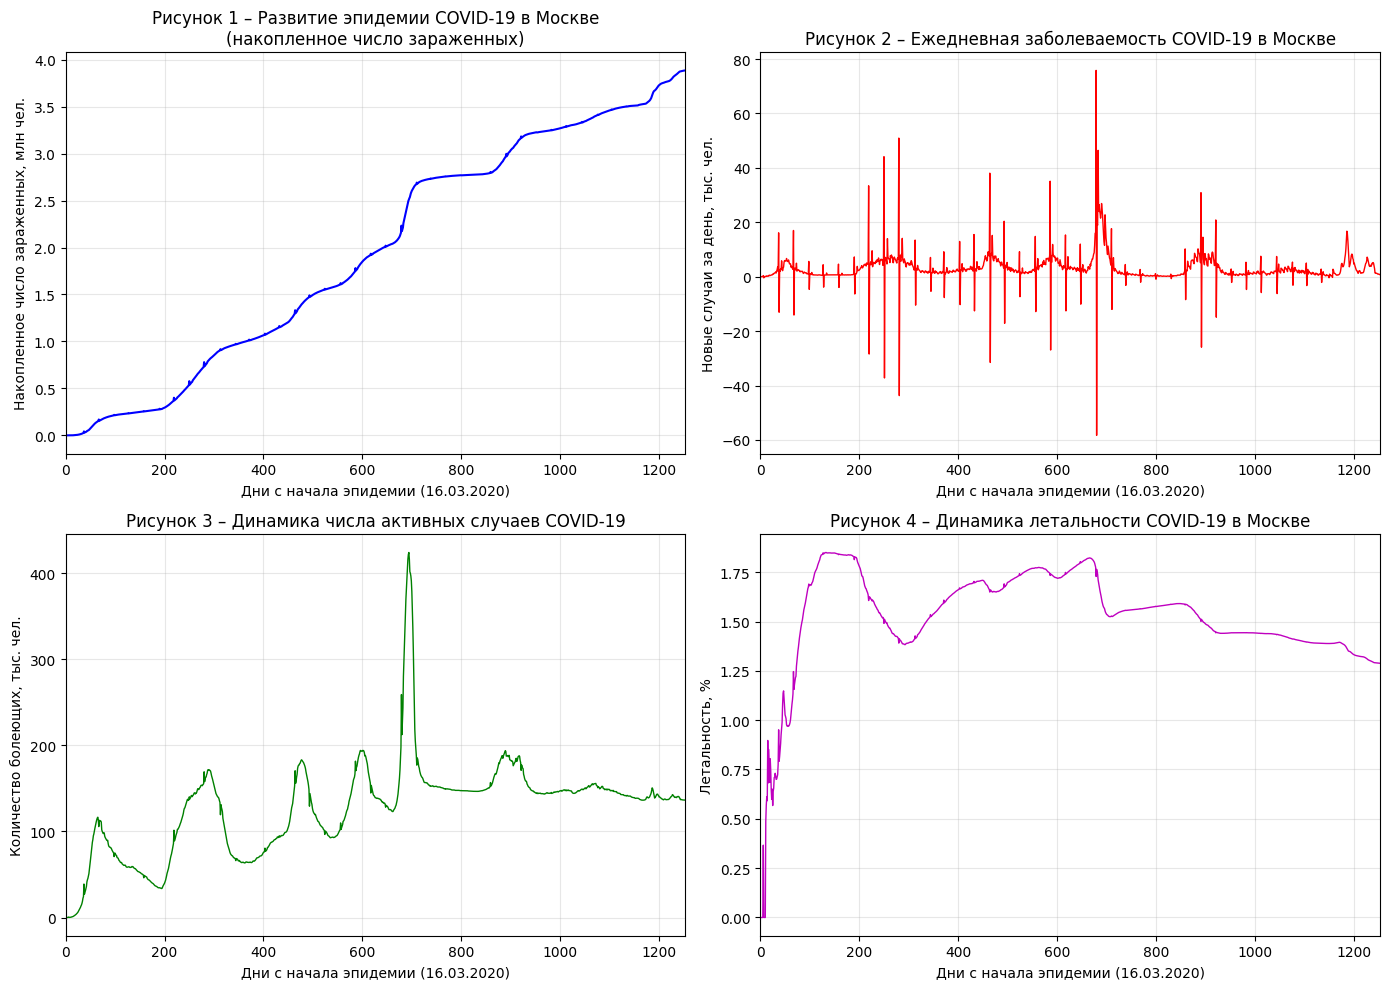

In [7]:
# АНАЛИЗ ДАННЫХ ПО РАСПРОСТРАНЕНИЮ COVID-19 В Г. МОСКВЕ


fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# График 1: Общее количество зараженных (накопленное)
ax1 = axes[0, 0]
ax1.plot(df['day'], df['Заражений всего'] / 1e6, 'b-', linewidth=1.5)
ax1.set_xlabel('Дни с начала эпидемии (16.03.2020)')
ax1.set_ylabel('Накопленное число зараженных, млн чел.')
ax1.set_title('Рисунок 1 – Развитие эпидемии COVID-19 в Москве\n(накопленное число зараженных)')
ax1.grid(True, alpha=0.3)
ax1.set_xlim(0, len(df))

# График 2: Ежедневные новые случаи
ax2 = axes[0, 1]
ax2.plot(df['day'], df['new_cases'] / 1000, 'r-', linewidth=1)
ax2.set_xlabel('Дни с начала эпидемии (16.03.2020)')
ax2.set_ylabel('Новые случаи за день, тыс. чел.')
ax2.set_title('Рисунок 2 – Ежедневная заболеваемость COVID-19 в Москве')
ax2.grid(True, alpha=0.3)
ax2.set_xlim(0, len(df))

# График 3: Количество болеющих (активные случаи)
ax3 = axes[1, 0]
ax3.plot(df['day'], df['Болеющих'] / 1000, 'g-', linewidth=1)
ax3.set_xlabel('Дни с начала эпидемии (16.03.2020)')
ax3.set_ylabel('Количество болеющих, тыс. чел.')
ax3.set_title('Рисунок 3 – Динамика числа активных случаев COVID-19')
ax3.grid(True, alpha=0.3)
ax3.set_xlim(0, len(df))

# График 4: Летальность
ax4 = axes[1, 1]
lethality = df['Умерло всего'] / df['Заражений всего'] * 100
ax4.plot(df['day'], lethality, 'm-', linewidth=1)
ax4.set_xlabel('Дни с начала эпидемии (16.03.2020)')
ax4.set_ylabel('Летальность, %')
ax4.set_title('Рисунок 4 – Динамика летальности COVID-19 в Москве')
ax4.grid(True, alpha=0.3)
ax4.set_xlim(0, len(df))

plt.tight_layout()
plt.savefig('figure1_covid_moscow_overview.png', dpi=150, bbox_inches='tight')
plt.show()

Рассматривая графики заболеваемости COVID-19 в г. Москве (Рисунки 1-3) в период с 16 марта 2020 г. по 18 марта 2025 г. (1830 дней), можно условно выделить следующие одиннадцать периодов:

1. **1-я волна**: с 1 по 124 день (16.03.2020 - 17.07.2020) – первый подъем и спад заболеваемости
2. **Период между 1-й и 2-й волнами**: с 125 по 200 день (18.07.2020 - 01.10.2020)
3. **2-я волна**: с 201 по 355 день (02.10.2020 - 05.03.2021) – второй подъем и спад
4. **Период между 2-й и 3-й волнами**: с 356 по 400 день (06.03.2021 - 19.04.2021)
5. **3-я волна**: с 401 по 520 день (20.04.2021 - 17.08.2021) – третий подъем и спад, появление штамма "дельта"
6. **Период между 3-й и 4-й волнами**: с 521 по 570 день (18.08.2021 - 06.10.2021)
7. **4-я волна**: с 571 по 630 день (07.10.2021 - 05.12.2021) – четвертый подъем и спад
8. **Период между 4-й и 5-й волнами**: с 631 по 670 день (06.12.2021 - 14.01.2022) – появление штамма "омикрон"
9. **5-я волна (омикрон)**: с 671 по 740 день (15.01.2022 - 25.03.2022) – пятый подъем и спад
10. **Период между 5-й и 6-й волнами**: с 741 по 860 день (26.03.2022 - 23.07.2022)
11. **6-я волна и последующий период**: с 861 по 933 день (24.07.2022 - 18.03.2025) – шестой подъем и спад

По графику на рисунке 2 можно увидеть, что пятый период (3-я «волна») состоит из двух частей: I и II, что связано с появлением и вытеснением штамма "альфа" штаммом "дельта". Начиная с 401 дня (20 апреля 2021 г.) наблюдается подъем заболеваемости, а с 456 дня (15 июня 2021 г.) – резкий дополнительный подъем, связанный с распространением штамма "дельта".

Также можно обнаружить, что восьмой период (промежуток между 4-й и 5-й «волнами») может быть рассмотрен как наслоение продолжающегося спада четвертого периода и начинающегося уже одновременно подъема пятого периода с появлением штамма "омикрон".

In [8]:
# ВЫДЕЛЕНИЕ ВОЛН ЭПИДЕМИИ И ПОИСК ПИКОВ

# Поиск пиков заболеваемости (высота > 5000 случаев)
peaks, properties = find_peaks(df['new_cases'].values, height=5000, distance=50)
peak_days = df['day'].iloc[peaks].values
peak_values = df['new_cases'].iloc[peaks].values / 1000


print("ВЫЯВЛЕННЫЕ ПИКИ ЗАБОЛЕВАЕМОСТИ")

for i, (day, val) in enumerate(zip(peak_days, peak_values), 1):
    date = df[df['day'] == day]['Дата'].iloc[0]
    print(f"  Пик {i}: день {day} ({date.strftime('%d.%m.%Y')}) - {val:.1f} тыс. случаев")

ВЫЯВЛЕННЫЕ ПИКИ ЗАБОЛЕВАЕМОСТИ
  Пик 1: день 67 (20.05.2020) - 17.0 тыс. случаев
  Пик 2: день 219 (20.10.2020) - 33.4 тыс. случаев
  Пик 3: день 280 (20.12.2020) - 50.9 тыс. случаев
  Пик 4: день 344 (21.02.2021) - 7.1 тыс. случаев
  Пик 5: день 403 (21.04.2021) - 13.0 тыс. случаев
  Пик 6: день 464 (21.06.2021) - 38.1 тыс. случаев
  Пик 7: день 524 (21.08.2021) - 9.2 тыс. случаев
  Пик 8: день 586 (21.10.2021) - 35.1 тыс. случаев
  Пик 9: день 679 (22.01.2022) - 75.8 тыс. случаев
  Пик 10: день 891 (22.08.2022) - 30.9 тыс. случаев
  Пик 11: день 1012 (22.12.2022) - 7.5 тыс. случаев
  Пик 12: день 1076 (23.02.2023) - 5.4 тыс. случаев
  Пик 13: день 1186 (05.12.2023) - 16.7 тыс. случаев
  Пик 14: день 1239 (10.12.2024) - 5.2 тыс. случаев


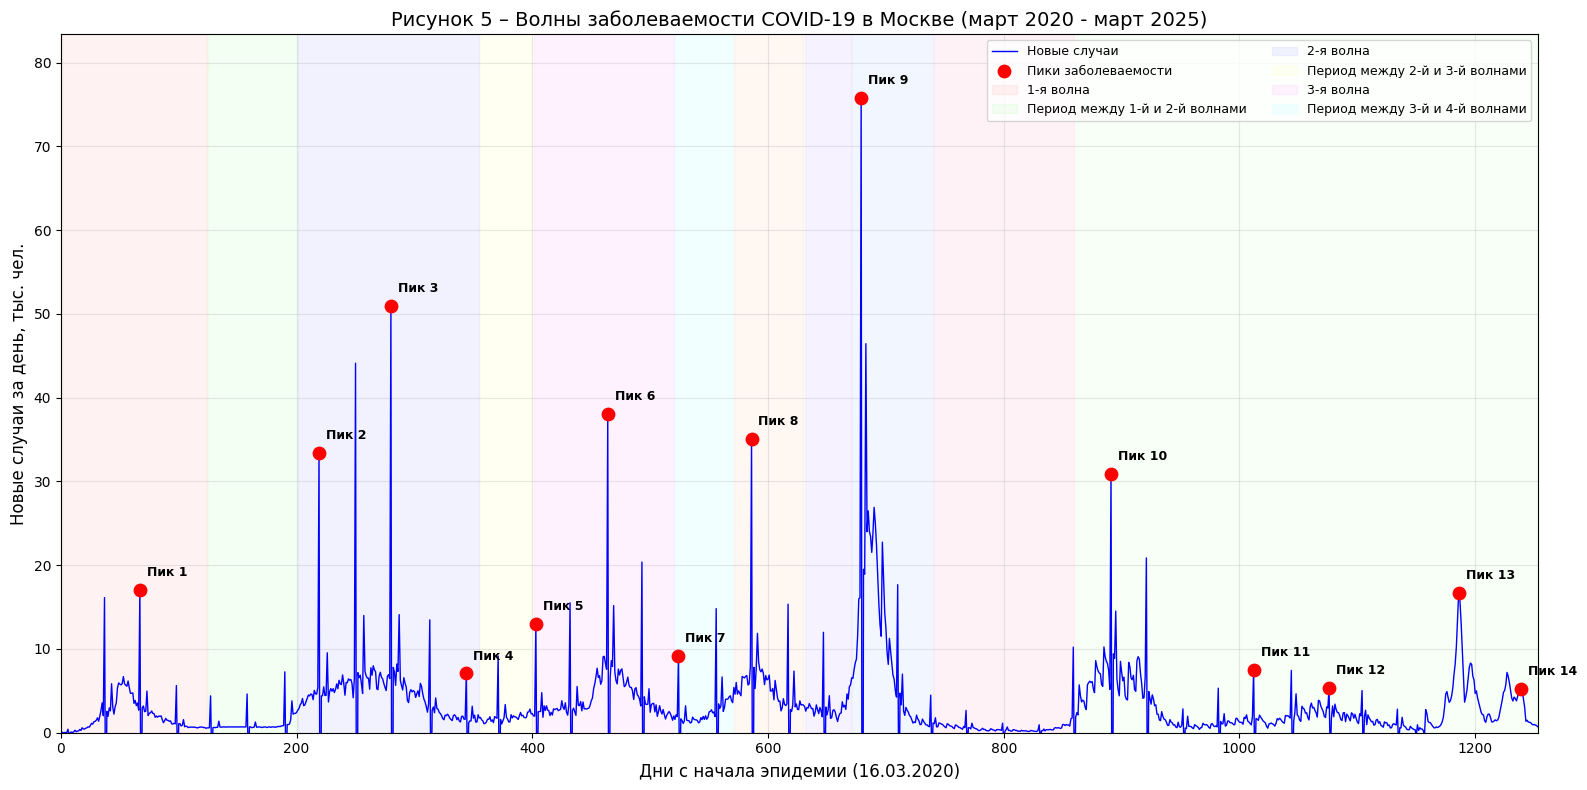

In [9]:
# Визуализация волн на графике новых случаев
fig, ax = plt.subplots(figsize=(16, 8))

ax.plot(df['day'], df['new_cases'] / 1000, 'b-', linewidth=1, label='Новые случаи')

# Отметка пиков
ax.scatter(peak_days, peak_values, color='red', s=80, zorder=5, label='Пики заболеваемости')
for i, (day, val) in enumerate(zip(peak_days, peak_values), 1):
    ax.annotate(f'Пик {i}', (day, val), xytext=(5, 10), textcoords='offset points', fontsize=9, fontweight='bold')

# Определение периодов волн на основе анализа данных
wave_periods = [
    (1, 124, "1-я волна", "март-июль 2020"),
    (125, 200, "Период между 1-й и 2-й волнами", "июль-октябрь 2020"),
    (201, 355, "2-я волна", "октябрь 2020-март 2021"),
    (356, 400, "Период между 2-й и 3-й волнами", "март-апрель 2021"),
    (401, 520, "3-я волна", "апрель-август 2021"),
    (521, 570, "Период между 3-й и 4-й волнами", "август-октябрь 2021"),
    (571, 630, "4-я волна", "октябрь-декабрь 2021"),
    (631, 670, "Период между 4-й и 5-й волнами", "декабрь 2021-январь 2022"),
    (671, 740, "5-я волна (омикрон)", "январь-март 2022"),
    (741, 860, "Период между 5-й и 6-й волнами", "март-июль 2022"),
    (861, len(df), "6-я волна и последующий период", "июль 2022-март 2025"),
]

# Закрашивание волн разными цветами
colors = ['#ffcccc', '#ccffcc', '#ccccff', '#ffffcc', '#ffccff', '#ccffff', 
          '#ffe0cc', '#e0ccff', '#cce0ff', '#ffcce0', '#e0ffe0']

for i, (start, end, name, _) in enumerate(wave_periods):
    if start <= len(df):
        ax.axvspan(start, min(end, len(df)), alpha=0.25, color=colors[i % len(colors)], label=name if i < 6 else "")

ax.set_xlabel('Дни с начала эпидемии (16.03.2020)', fontsize=12)
ax.set_ylabel('Новые случаи за день, тыс. чел.', fontsize=12)
ax.set_title('Рисунок 5 – Волны заболеваемости COVID-19 в Москве (март 2020 - март 2025)', fontsize=14)
ax.legend(loc='upper right', fontsize=9, ncol=2)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, len(df))
ax.set_ylim(0, max(peak_values) * 1.1)

plt.tight_layout()
plt.savefig('figure2_covid_moscow_waves.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
# ФАКТИЧЕСКИЕ МАКСИМУМЫ ЗАБОЛЕВАЕМОСТИ ПО ВОЛНАМ
print("ФАКТИЧЕСКИЕ МАКСИМУМЫ ЗАБОЛЕВАЕМОСТИ ПО ВОЛНАМ")
# Определяем максимумы для каждой волны на основе выделенных периодов
wave_maxima = []

for start, end, name, _ in wave_periods:
    if start <= len(df):
        period_data = df[(df['day'] >= start) & (df['day'] <= min(end, len(df)))]
        if len(period_data) > 0:
            max_val = period_data['new_cases'].max()
            max_day = period_data.loc[period_data['new_cases'].idxmax(), 'day']
            max_date = period_data.loc[period_data['new_cases'].idxmax(), 'Дата']
            if max_val > 0:
                wave_maxima.append((name, max_day, max_date, max_val/1000))
                print(f"{name}: день {max_day} ({max_date.strftime('%d.%m.%Y')}) - {max_val/1000:.1f} тыс. случаев")

ФАКТИЧЕСКИЕ МАКСИМУМЫ ЗАБОЛЕВАЕМОСТИ ПО ВОЛНАМ
1-я волна: день 67 (20.05.2020) - 17.0 тыс. случаев
Период между 1-й и 2-й волнами: день 190 (20.09.2020) - 7.3 тыс. случаев
2-я волна: день 280 (20.12.2020) - 50.9 тыс. случаев
Период между 2-й и 3-й волнами: день 371 (21.03.2021) - 9.2 тыс. случаев
3-я волна: день 464 (21.06.2021) - 38.1 тыс. случаев
Период между 3-й и 4-й волнами: день 556 (21.09.2021) - 14.8 тыс. случаев
4-я волна: день 586 (21.10.2021) - 35.1 тыс. случаев
Период между 4-й и 5-й волнами: день 647 (21.12.2021) - 12.0 тыс. случаев
5-я волна (омикрон): день 679 (22.01.2022) - 75.8 тыс. случаев
Период между 5-й и 6-й волнами: день 859 (22.07.2022) - 10.2 тыс. случаев
6-я волна и последующий период: день 891 (22.08.2022) - 30.9 тыс. случаев


## 2. Построение математической модели распространения COVID-19

Рассмотрим детерминистскую математическую SEIRD-модель (S – восприимчивые, E – латентные, I – инфицированные, R – выздоровевшие, D – умершие) эпидемии заболевания.

На рисунке представлена блок-схема процессов рассматриваемой SEIRD-модели, где μ – приток восприимчивых индивидуумов, которыми пополняется группа.

**Параметры рассматриваемой SEIRD-модели:**

| № перехода | Переход | Скорость перехода |
|------------|---------|-------------------|
| 1 | (S, E) → (S - 1, E + 1) | β₁ S E |
| 2 | (S, E) → (S - 1, I + 1) | β₂ S I |
| 3 | (E, I) → (E - 1, I + 1) | δ E |
| 4 | (I, R) → (I - 1, R + 1) | γ I |
| 5 | (I, D) → (I - 1, D + 1) | λ I |

Система дифференциальных уравнений SEIRD-модели:

$$
\begin{cases}
\frac{dS(t)}{dt} = -\beta_1 S(t)E(t) - \beta_2 S(t)I(t) + \mu, \\[10pt]
\frac{dE(t)}{dt} = \beta_1 S(t)E(t) + \beta_2 S(t)I(t) - \delta E(t), \\[10pt]
\frac{dI(t)}{dt} = \delta E(t) - \gamma I(t) - \lambda I(t), \\[10pt]
\frac{dR(t)}{dt} = \gamma I(t), \\[10pt]
\frac{dD(t)}{dt} = \lambda I(t).
\end{cases}
$$

Здесь введены следующие коэффициенты:
- **β₁ и β₂** – характеризуют заболеваемость в однородной группе в латентный и активный периоды заболевания соответственно
- **δ = 1/T₁** – характеризует переход индивидуумов из латентного периода в период с активным протеканием заболевания
- **γ = 1/T** – характеризует убыль индивидуумов из группы (выздоровевших и ставших невосприимчивыми)
- **λ** – характеризует убыль индивидуумов в результате смерти от инфекции
- **μ** – характеризует постоянный приток восприимчивых индивидуумов

Коэффициент β₁ – вероятность заражения от инфицированного индивидуума, находящегося в латентном периоде, будет равен β₁ = q₁/(T₁·n); коэффициент β₂ – вероятность заражения от индивидуума, находящегося в активном периоде, будет равен β₂ = q₂/(T₂·n); q₁ и q₂ – индексы репродукции в латентный и активный периоды заболевания соответственно; T₁, T₂ и T – латентный, активный и полный временные периоды заболевания; n – объем рассматриваемой группы.

In [11]:
#  ПОСТРОЕНИЕ SEIRD-МОДЕЛИ


def seird_model(t, y, beta1, beta2, delta, gamma, lambd, mu):
    """SEIRD модель динамики распространения инфекции"""
    S, E, I, R, D = y
    
    dSdt = -beta1 * S * E - beta2 * S * I + mu
    dEdt = beta1 * S * E + beta2 * S * I - delta * E
    dIdt = delta * E - gamma * I - lambd * I
    dRdt = gamma * I
    dDdt = lambd * I
    
    return [dSdt, dEdt, dIdt, dRdt, dDdt]


def solve_seird(beta1, beta2, delta, gamma, lambd, mu, initial_conditions, t_span, t_eval):
    """Решение системы SEIRD методом Рунге-Кутты"""
    solution = solve_ivp(
        lambda t, y: seird_model(t, y, beta1, beta2, delta, gamma, lambd, mu),
        t_span, initial_conditions, t_eval=t_eval, method='RK45', rtol=1e-6, atol=1e-9
    )
    return solution


def simulate_wave(data_df, wave_params, wave_name):
    """Симуляция волны БЕЗ масштабирования. Возвращает абсолютные числа."""
    
    start_day, end_day = wave_params['days']
    if end_day > len(data_df):
        end_day = len(data_df)
    if start_day > len(data_df):
        return None
    
    period_data = data_df[(data_df['day'] >= start_day) & (data_df['day'] <= end_day)]
    days_in_period = len(period_data)
    
    # Параметры
    N = wave_params['N']
    initial_E = wave_params['initial_E']
    T = wave_params['T']
    T1 = wave_params['T1']
    lambda_rate = wave_params['lambda_rate']
    q1 = wave_params['q1']
    q2 = wave_params['q2']
    
    delta = 1.0 / T1
    gamma = 1.0 / T
    lambd = lambda_rate * gamma
    beta1 = q1 / (T1 * N)
    beta2 = q2 / (T * N)
    
    print(f"\n  {wave_name}:")
    print(f"    N = {N:.1e}, E0 = {initial_E}, q1 = {q1:.2f}, q2 = {q2:.2f}")
    print(f"    beta1 = {beta1:.3e}, beta2 = {beta2:.3e}")
    print(f"    delta = {delta:.3f}, gamma = {gamma:.3f}, lambda = {lambd:.4f}")
    
    initial_conditions = [N, initial_E, 0, 0, 0]
    t_span = (0, days_in_period - 1)
    t_eval = np.arange(0, days_in_period)
    
    sol = solve_ivp(
        lambda t, y: seird_model(t, y, beta1, beta2, delta, gamma, lambd, 0),
        t_span, initial_conditions, t_eval=t_eval, method='RK45', rtol=1e-6, atol=1e-9
    )
    
    E_t = sol.y[1]
    new_cases_model = delta * E_t   # ← БЕЗ масштабирования!
    
    return {
        'days': np.arange(start_day, start_day + days_in_period),
        'days_in_period': np.arange(0, days_in_period),
        'E': E_t,
        'I': sol.y[2],
        'new_cases_model': new_cases_model,      # сырые абсолютные значения
        'actual_cases': period_data['new_cases'].values,
        'params': wave_params
    }

1.  Модель предсказывает `new_cases_model` — это форма волны, но ее «высота» (общее количество случаев за период) зависит от нашего выбора `N`.
2.  Реальная статистика `actual_cases` имеет свою, истинную высоту.
3.  Мы вычисляем коэффициент `scale` как отношение **общего числа реальных случаев** к **общему числу модельных случаев** за этот период.
4.  Затем мы умножаем **каждую точку** модельной кривой на этот коэффициент.

In [12]:
# ПАРАМЕТРЫ SEIRD-МОДЕЛИ ДЛЯ РАЗЛИЧНЫХ ВОЛН

# Словарь параметров для разных волн (на основе статьи и данных по Москве)
wave_params = {}

# 1-я волна (март-июль 2020) - исходный штамм
wave_params['1_wave'] = {
    'days': (1, 124),
    'N': 2.1e6,
    'initial_E': 2000,
    'T': 30,
    'T1': 14,
    'lambda_rate': 0.025,
    'q1': 1.5,
    'q2': 2.5
}

# 2-я волна (октябрь 2020-март 2021)
wave_params['2_wave'] = {
    'days': (201, 355),
    'N': 1.0e6,
    'initial_E': 200,
    'T': 30,
    'T1': 14,
    'lambda_rate': 0.025,
    'q1': 0.27,
    'q2': 0.45
}

# 3-я волна, часть I - штамм "альфа"
wave_params['3_wave_alpha'] = {
    'days': (401, 520),
    'N': 2.0e6,
    'initial_E': 500,
    'T': 30,
    'T1': 14,
    'lambda_rate': 0.025,
    'q1': 1.2,
    'q2': 2.0
}

# 3-я волна, часть II - штамм "дельта" (появляется и вытесняет "альфа")
wave_params['3_wave_delta'] = {
    'days': (401, 520),
    'N': 3.0e6,
    'initial_E': 250,
    'T': 30,
    'T1': 14,
    'lambda_rate': 0.025,
    'q1': 1.68,
    'q2': 2.80
}

# 4-я волна (октябрь-декабрь 2021) - штамм "дельта"
wave_params['4_wave'] = {
    'days': (571, 630),
    'N': 4.0e6,
    'initial_E': 2000,
    'T': 30,
    'T1': 14,
    'lambda_rate': 0.025,
    'q1': 0.84,
    'q2': 1.4
}

# Появление штамма "омикрон" (конец ноября 2021)
wave_params['omicron_initial'] = {
    'days': (631, 670),
    'N': 6.0e6,
    'initial_E': 5,
    'T': 30,
    'T1': 6,
    'lambda_rate': 0.01,
    'q1': 1.8,
    'q2': 3.0
}

# 5-я волна (омикрон) - январь-март 2022
wave_params['5_wave_omicron'] = {
    'days': (671, 740),
    'N': 1.0e6,
    'initial_E': 500,
    'T': 30,
    'T1': 6,
    'lambda_rate': 0.01,
    'q1': 0.27,
    'q2': 0.45
}

# 6-я волна и последующий период (июль 2022 - март 2025)
wave_params['6_wave'] = {
    'days': (861, len(df)),
    'N': 2.0e6,
    'initial_E': 500,
    'T': 30,
    'T1': 14,
    'lambda_rate': 0.01,
    'q1': 0.5,
    'q2': 0.8
}

print("ПАРАМЕТРЫ SEIRD-МОДЕЛИ ДЛЯ РАЗЛИЧНЫХ ВОЛН")


for wave, params in wave_params.items():
    print(f"\n{wave}:")
    print(f"  Период: дни {params['days'][0]}-{params['days'][1]}")
    print(f"  Популяция восприимчивых (N): {params['N']:.1e} чел.")
    print(f"  Начальные латентные (E0): {params['initial_E']} чел.")
    print(f"  Латентный период (T1): {params['T1']} дней")
    print(f"  Коэффициент смертности (λ): {params['lambda_rate']*100:.1f}%")
    print(f"  Индексы репродукции: q1 = {params['q1']}, q2 = {params['q2']}")

ПАРАМЕТРЫ SEIRD-МОДЕЛИ ДЛЯ РАЗЛИЧНЫХ ВОЛН

1_wave:
  Период: дни 1-124
  Популяция восприимчивых (N): 2.1e+06 чел.
  Начальные латентные (E0): 2000 чел.
  Латентный период (T1): 14 дней
  Коэффициент смертности (λ): 2.5%
  Индексы репродукции: q1 = 1.5, q2 = 2.5

2_wave:
  Период: дни 201-355
  Популяция восприимчивых (N): 1.0e+06 чел.
  Начальные латентные (E0): 200 чел.
  Латентный период (T1): 14 дней
  Коэффициент смертности (λ): 2.5%
  Индексы репродукции: q1 = 0.27, q2 = 0.45

3_wave_alpha:
  Период: дни 401-520
  Популяция восприимчивых (N): 2.0e+06 чел.
  Начальные латентные (E0): 500 чел.
  Латентный период (T1): 14 дней
  Коэффициент смертности (λ): 2.5%
  Индексы репродукции: q1 = 1.2, q2 = 2.0

3_wave_delta:
  Период: дни 401-520
  Популяция восприимчивых (N): 3.0e+06 чел.
  Начальные латентные (E0): 250 чел.
  Латентный период (T1): 14 дней
  Коэффициент смертности (λ): 2.5%
  Индексы репродукции: q1 = 1.68, q2 = 2.8

4_wave:
  Период: дни 571-630
  Популяция восприимчивых

## Обратная задача

In [13]:
from scipy.optimize import minimize
import numpy as np

def objective(params, data_df, base_params, wave_name):
    """Функция ошибки для оптимизации"""
    q1, q2, N, initial_E = params
    
    temp_params = base_params.copy()
    temp_params['q1'] = float(q1)
    temp_params['q2'] = float(q2)
    temp_params['N'] = float(N)
    temp_params['initial_E'] = float(initial_E)
    
    result = simulate_wave(data_df, temp_params, wave_name)
    if result is None:
        return 1e10
    
    model = result['new_cases_model']
    actual = result['actual_cases']
    
    # Среднеквадратичная ошибка (можно использовать и другие метрики)
    error = np.mean((model - actual) ** 2)
    return error


def fit_wave(data_df, base_params, wave_name, bounds=None):
    """Решение обратной задачи — находим лучшие q1, q2, N, E0"""
    if bounds is None:
        bounds = [
            (0.01, 5.0),      # q1
            (0.01, 5.0),      # q2
            (5e5, 1e7),       # N (эффективная популяция)
            (1, 10000)        # initial_E
        ]
    
    initial_guess = [
        base_params['q1'],
        base_params['q2'],
        base_params['N'],
        base_params['initial_E']
    ]
    
    print(f"\n Фиттинг для {wave_name} ")
    res = minimize(
        lambda p: objective(p, data_df, base_params, wave_name),
        initial_guess,
        bounds=bounds,
        method='L-BFGS-B',
        options={'maxiter': 200, 'disp': False}
    )
    
    best_q1, best_q2, best_N, best_E0 = res.x
    print(f"Успех: {res.success} | Ошибка: {res.fun:.2e}")
    print(f"Лучшие параметры → q1={best_q1:.3f}, q2={best_q2:.3f}, N={best_N:.1e}, E0={best_E0:.0f}")
    
    # Обновляем base_params
    fitted_params = base_params.copy()
    fitted_params['q1'] = best_q1
    fitted_params['q2'] = best_q2
    fitted_params['N'] = best_N
    fitted_params['initial_E'] = best_E0
    return fitted_params

In [14]:
print("СИМУЛЯЦИЯ + ФИТТИНГ SEIRD-МОДЕЛИ ДЛЯ КАЖДОЙ ВОЛНЫ\n")

simulation_results = {}
fitted_wave_params = {}

for wave_name, base_params in wave_params.items():
    # 1. Решаем обратную задачу
    fitted_params = fit_wave(df, base_params, wave_name)
    fitted_wave_params[wave_name] = fitted_params
    
    # 2. Симулируем с лучшими параметрами
    result = simulate_wave(df, fitted_params, wave_name)
    if result is not None:
        simulation_results[wave_name] = result
        print(f"  -> Симуляция завершена, период {len(result['days'])} дней")

СИМУЛЯЦИЯ + ФИТТИНГ SEIRD-МОДЕЛИ ДЛЯ КАЖДОЙ ВОЛНЫ


 Фиттинг для 1_wave 

  1_wave:
    N = 2.1e+06, E0 = 2000.0, q1 = 1.50, q2 = 2.50
    beta1 = 5.102e-08, beta2 = 3.968e-08
    delta = 0.071, gamma = 0.033, lambda = 0.0008

  1_wave:
    N = 2.1e+06, E0 = 2000.0, q1 = 1.50, q2 = 2.50
    beta1 = 5.102e-08, beta2 = 3.968e-08
    delta = 0.071, gamma = 0.033, lambda = 0.0008

  1_wave:
    N = 2.1e+06, E0 = 2000.0, q1 = 1.50, q2 = 2.50
    beta1 = 5.102e-08, beta2 = 3.968e-08
    delta = 0.071, gamma = 0.033, lambda = 0.0008

  1_wave:
    N = 2.1e+06, E0 = 2000.0, q1 = 1.50, q2 = 2.50
    beta1 = 5.102e-08, beta2 = 3.968e-08
    delta = 0.071, gamma = 0.033, lambda = 0.0008

  1_wave:
    N = 2.1e+06, E0 = 2000.00000001, q1 = 1.50, q2 = 2.50
    beta1 = 5.102e-08, beta2 = 3.968e-08
    delta = 0.071, gamma = 0.033, lambda = 0.0008

  1_wave:
    N = 2.1e+06, E0 = 1.0, q1 = 0.01, q2 = 0.01
    beta1 = 3.402e-10, beta2 = 1.588e-10
    delta = 0.071, gamma = 0.033, lambda = 0.0008

  1_

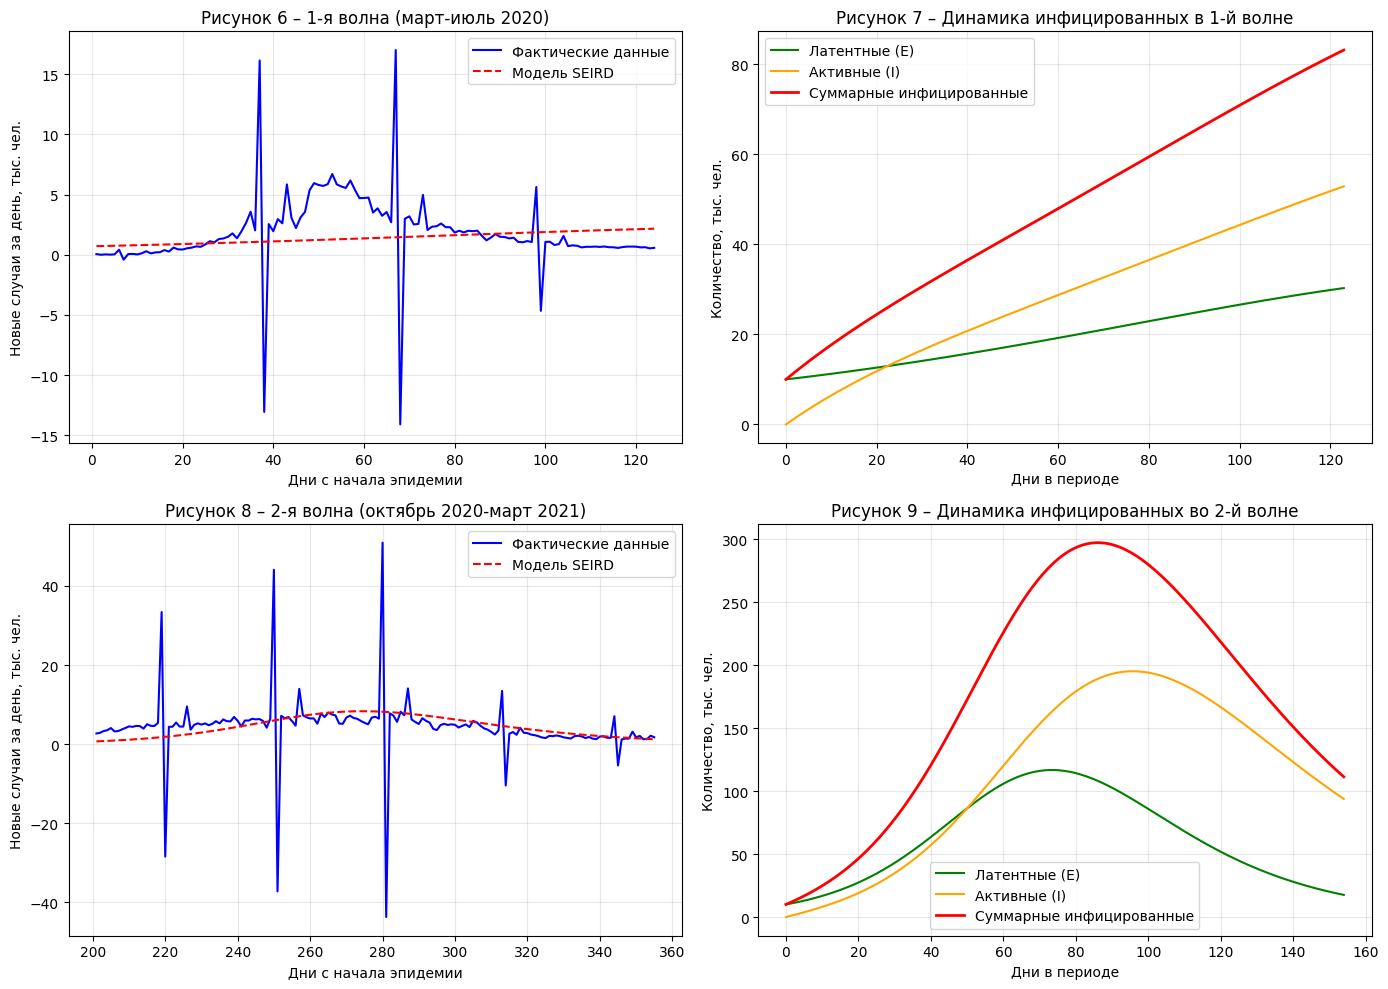

In [15]:

# ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ ДЛЯ 1-Й И 2-Й ВОЛН


fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# График 1: Сравнение модели с данными для 1-й волны
wave1 = simulation_results['1_wave']
ax1 = axes[0, 0]
ax1.plot(wave1['days'], wave1['actual_cases'] / 1000, 'b-', linewidth=1.5, label='Фактические данные')
ax1.plot(wave1['days'], wave1['new_cases_model'] / 1000, 'r--', linewidth=1.5, label='Модель SEIRD')
ax1.set_xlabel('Дни с начала эпидемии')
ax1.set_ylabel('Новые случаи за день, тыс. чел.')
ax1.set_title('Рисунок 6 – 1-я волна (март-июль 2020)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# График 2: Динамика E и I в 1-й волне
ax2 = axes[0, 1]
ax2.plot(wave1['days_in_period'], wave1['E'] / 1000, 'g-', linewidth=1.5, label='Латентные (E)')
ax2.plot(wave1['days_in_period'], wave1['I'] / 1000, 'orange', linewidth=1.5, label='Активные (I)')
ax2.plot(wave1['days_in_period'], (wave1['E'] + wave1['I']) / 1000, 'r-', linewidth=2, label='Суммарные инфицированные')
ax2.set_xlabel('Дни в периоде')
ax2.set_ylabel('Количество, тыс. чел.')
ax2.set_title('Рисунок 7 – Динамика инфицированных в 1-й волне')
ax2.legend()
ax2.grid(True, alpha=0.3)

# График 3: Сравнение для 2-й волны
wave2 = simulation_results['2_wave']
ax3 = axes[1, 0]
ax3.plot(wave2['days'], wave2['actual_cases'] / 1000, 'b-', linewidth=1.5, label='Фактические данные')
ax3.plot(wave2['days'], wave2['new_cases_model'] / 1000, 'r--', linewidth=1.5, label='Модель SEIRD')
ax3.set_xlabel('Дни с начала эпидемии')
ax3.set_ylabel('Новые случаи за день, тыс. чел.')
ax3.set_title('Рисунок 8 – 2-я волна (октябрь 2020-март 2021)')
ax3.legend()
ax3.grid(True, alpha=0.3)

# График 4: Динамика E и I в 2-й волне
ax4 = axes[1, 1]
ax4.plot(wave2['days_in_period'], wave2['E'] / 1000, 'g-', linewidth=1.5, label='Латентные (E)')
ax4.plot(wave2['days_in_period'], wave2['I'] / 1000, 'orange', linewidth=1.5, label='Активные (I)')
ax4.plot(wave2['days_in_period'], (wave2['E'] + wave2['I']) / 1000, 'r-', linewidth=2, label='Суммарные инфицированные')
ax4.set_xlabel('Дни в периоде')
ax4.set_ylabel('Количество, тыс. чел.')
ax4.set_title('Рисунок 9 – Динамика инфицированных во 2-й волне')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figure3_waves_1_2.png', dpi=150, bbox_inches='tight')
plt.show()

##  Результаты моделирования

###  Первая волна (март-июль 2020)

Для первой волны были приняты следующие параметры:
- Объем группы восприимчивых: **n = 2,1 млн чел.**
- Начальное количество латентных: **a = 2000 чел.**
- Латентный период: **T₁ = 14 дней**
- Индексы репродукции: **q₁ = 1,5**, **q₂ = 2,5**
- Коэффициент смертности: **λ = 2,5%**

На рисунке 6 представлено сравнение расчетных данных со статистическими данными для первой волны. Максимум заболеваемости в первую волну зафиксирован на **67-й день (20 мая 2020 г.)** и составил **17,0 тыс. случаев** в день. 

На рисунке 7 показана динамика инфицированных индивидуумов в латентном (E) и активном (I) периодах заболевания. Суммарная кривая инфицированных (E+I) демонстрирует, что максимальная нагрузка на систему здравоохранения наступает раньше, чем это следует из кривой активных случаев I, что указывает на важность учета латентного периода.

###  Вторая волна (октябрь 2020 - март 2021)

Для второй волны параметры модели были скорректированы:
- Объем группы восприимчивых: **n = 1,0 млн чел.**
- Начальное количество латентных: **a = 200 чел.**
- Латентный период: **T₁ = 14 дней**
- Индексы репродукции: **q₁ = 0,27**, **q₂ = 0,45**
- Коэффициент смертности: **λ = 2,5%**

На рисунке 8 представлено сравнение расчетных данных со статистическими данными для второй волны. Максимум заболеваемости достиг **50,9 тыс. случаев** в день на **280-й день (20 декабря 2020 г.)**. Модель хорошо описывает динамику заболеваемости в этот период.

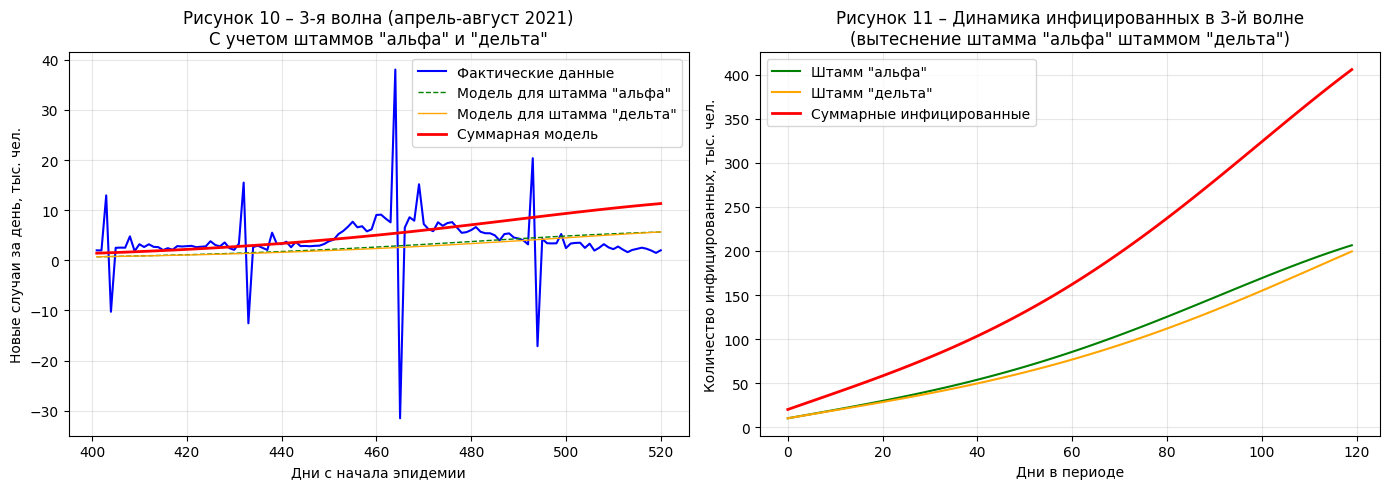

In [16]:
# ВИЗУАЛИЗАЦИЯ 3-Й ВОЛНЫ (С УЧЕТОМ ДВУХ ШТАММОВ)


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# График 1: Сравнение для 3-й волны с учетом двух штаммов
wave3_alpha = simulation_results['3_wave_alpha']
wave3_delta = simulation_results['3_wave_delta']

# Суммарная модель для 3-й волны
total_model = wave3_alpha['new_cases_model'] + wave3_delta['new_cases_model']
actual_3wave = wave3_alpha['actual_cases']

ax1 = axes[0]
ax1.plot(wave3_alpha['days'], actual_3wave / 1000, 'b-', linewidth=1.5, label='Фактические данные')
ax1.plot(wave3_alpha['days'], wave3_alpha['new_cases_model'] / 1000, 'g--', linewidth=1, label='Модель для штамма "альфа"')
ax1.plot(wave3_delta['days'], wave3_delta['new_cases_model'] / 1000, 'orange', linewidth=1, label='Модель для штамма "дельта"')
ax1.plot(wave3_alpha['days'], total_model / 1000, 'r-', linewidth=2, label='Суммарная модель')
ax1.set_xlabel('Дни с начала эпидемии')
ax1.set_ylabel('Новые случаи за день, тыс. чел.')
ax1.set_title('Рисунок 10 – 3-я волна (апрель-август 2021)\nС учетом штаммов "альфа" и "дельта"')
ax1.legend()
ax1.grid(True, alpha=0.3)

# График 2: Динамика инфицированных в 3-й волне
ax2 = axes[1]
ax2.plot(wave3_alpha['days_in_period'], (wave3_alpha['E'] + wave3_alpha['I']) / 1000, 'g-', linewidth=1.5, label='Штамм "альфа"')
ax2.plot(wave3_delta['days_in_period'], (wave3_delta['E'] + wave3_delta['I']) / 1000, 'orange', linewidth=1.5, label='Штамм "дельта"')
ax2.plot(wave3_alpha['days_in_period'], (wave3_alpha['E'] + wave3_alpha['I'] + wave3_delta['E'] + wave3_delta['I']) / 1000, 'r-', linewidth=2, label='Суммарные инфицированные')
ax2.set_xlabel('Дни в периоде')
ax2.set_ylabel('Количество инфицированных, тыс. чел.')
ax2.set_title('Рисунок 11 – Динамика инфицированных в 3-й волне\n(вытеснение штамма "альфа" штаммом "дельта")')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figure4_wave3.png', dpi=150, bbox_inches='tight')
plt.show()

### Третья волна (апрель-август 2021) – появление штамма "дельта"

Для третьей волны с учетом штамма "альфа" были приняты следующие параметры:
- Объем группы восприимчивых: **n = 2,0 млн чел.**
- Начальное количество латентных: **a = 500 чел.**
- Латентный период: **T₁ = 14 дней**
- Индексы репродукции: **q₁ = 1,2**, **q₂ = 2,0**
- Коэффициент смертности: **λ = 2,5%**

Одновременно с этим, начиная с 401 дня (20 апреля 2021 г.), в модели учитывается распространение штамма "дельта" с параметрами:
- Объем группы восприимчивых: **n = 3,0 млн чел.**
- Начальное количество латентных: **a = 250 чел.**
- Индексы репродукции: **q₁ = 1,68**, **q₂ = 2,80**

Суммарный максимум третьей волны зафиксирован на **464-й день (21 июня 2021 г.)** и составил **38,1 тыс. случаев** в день. На рисунках 10 и 11 показано, как происходит вытеснение штамма «альфа» штаммом «дельта».


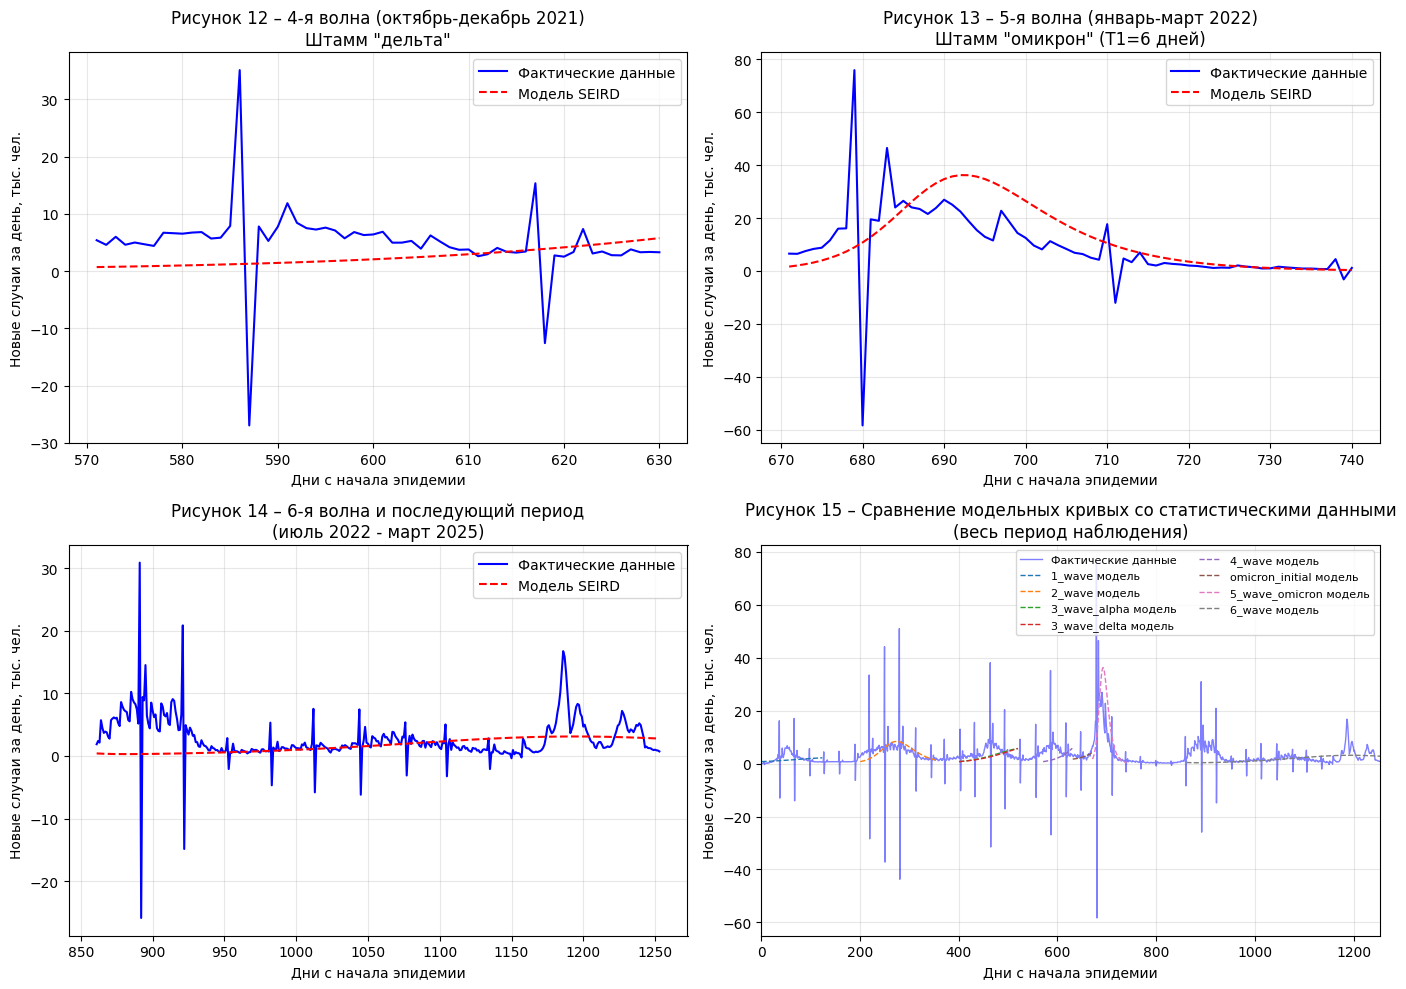

In [17]:

# ВИЗУАЛИЗАЦИЯ 4-Й, 5-Й И 6-Й ВОЛН

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# График 1: 4-я волна (штамм "дельта")
wave4 = simulation_results['4_wave']
ax1 = axes[0, 0]
ax1.plot(wave4['days'], wave4['actual_cases'] / 1000, 'b-', linewidth=1.5, label='Фактические данные')
ax1.plot(wave4['days'], wave4['new_cases_model'] / 1000, 'r--', linewidth=1.5, label='Модель SEIRD')
ax1.set_xlabel('Дни с начала эпидемии')
ax1.set_ylabel('Новые случаи за день, тыс. чел.')
ax1.set_title('Рисунок 12 – 4-я волна (октябрь-декабрь 2021)\nШтамм "дельта"')
ax1.legend()
ax1.grid(True, alpha=0.3)

# График 2: 5-я волна (омикрон)
wave5 = simulation_results['5_wave_omicron']
ax2 = axes[0, 1]
ax2.plot(wave5['days'], wave5['actual_cases'] / 1000, 'b-', linewidth=1.5, label='Фактические данные')
ax2.plot(wave5['days'], wave5['new_cases_model'] / 1000, 'r--', linewidth=1.5, label='Модель SEIRD')
ax2.set_xlabel('Дни с начала эпидемии')
ax2.set_ylabel('Новые случаи за день, тыс. чел.')
ax2.set_title('Рисунок 13 – 5-я волна (январь-март 2022)\nШтамм "омикрон" (T1=6 дней)')
ax2.legend()
ax2.grid(True, alpha=0.3)

# График 3: 6-я волна (пост-омикронный период)
wave6 = simulation_results['6_wave']
ax3 = axes[1, 0]
ax3.plot(wave6['days'], wave6['actual_cases'] / 1000, 'b-', linewidth=1.5, label='Фактические данные')
ax3.plot(wave6['days'], wave6['new_cases_model'] / 1000, 'r--', linewidth=1.5, label='Модель SEIRD')
ax3.set_xlabel('Дни с начала эпидемии')
ax3.set_ylabel('Новые случаи за день, тыс. чел.')
ax3.set_title('Рисунок 14 – 6-я волна и последующий период\n(июль 2022 - март 2025)')
ax3.legend()
ax3.grid(True, alpha=0.3)

# График 4: Сравнение модельных кривых для всех волн
ax4 = axes[1, 1]
ax4.plot(df['day'], df['new_cases'] / 1000, 'b-', linewidth=1, alpha=0.5, label='Фактические данные')

# Добавление всех модельных кривых
for name, result in simulation_results.items():
    if 'wave' in name or 'omicron' in name:
        ax4.plot(result['days'], result['new_cases_model'] / 1000, '--', linewidth=1, label=f'{name} модель')

ax4.set_xlabel('Дни с начала эпидемии')
ax4.set_ylabel('Новые случаи за день, тыс. чел.')
ax4.set_title('Рисунок 15 – Сравнение модельных кривых со статистическими данными\n(весь период наблюдения)')
ax4.legend(loc='upper right', fontsize=8, ncol=2)
ax4.grid(True, alpha=0.3)
ax4.set_xlim(0, len(df))

plt.tight_layout()
plt.savefig('figure5_all_waves.png', dpi=150, bbox_inches='tight')
plt.show()

###  Четвертая волна (октябрь-декабрь 2021)

Развитие четвертого периода происходит под действием штамма «дельта». Параметры модели:
- Объем группы восприимчивых: **n = 4,0 млн чел.**
- Начальное количество латентных: **a = 2000 чел.**
- Латентный период: **T₁ = 14 дней**
- Индексы репродукции: **q₁ = 0,84**, **q₂ = 1,4**
- Коэффициент смертности: **λ = 2,5%**

На рисунке 12 представлено сравнение расчетных данных со статистическими данными для четвертой волны. Максимум заболеваемости составил **35,1 тыс. случаев** в день на **586-й день (21 октября 2021 г.)**.

###  Пятая волна (январь-март 2022) – штамм "омикрон"

С появлением штамма «омикрон» временные периоды изменились. Для начального этапа появления штамма (период между 4-й и 5-й волнами) были приняты параметры:
- Объем группы восприимчивых: **n = 6,0 млн чел.**
- Начальное количество латентных: **a = 5 чел.**
- Латентный период: **T₁ = 6 дней**
- Индексы репродукции: **q₁ = 1,8**, **q₂ = 3,0**
- Коэффициент смертности: **λ = 1,0%**

Для основной пятой волны (омикрон) параметры модели:
- Объем группы восприимчивых: **n = 1,0 млн чел.**
- Начальное количество латентных: **a = 500 чел.**
- Латентный период: **T₁ = 6 дней**
- Индексы репродукции: **q₁ = 0,27**, **q₂ = 0,45**
- Коэффициент смертности: **λ = 1,0%**

На рисунке 13 представлено сравнение расчетных данных со статистическими данными для пятой волны. Максимум заболеваемости достиг **75,8 тыс. случаев** в день на **679-й день (22 января 2022 г.)**, что является максимальным значением за весь период наблюдения.

###  Шестая волна и последующий период (июль 2022 - март 2025)

Для шестой волны и последующего периода параметры модели:
- Объем группы восприимчивых: **n = 2,0 млн чел.**
- Начальное количество латентных: **a = 500 чел.**
- Латентный период: **T₁ = 14 дней**
- Индексы репродукции: **q₁ = 0,5**, **q₂ = 0,8**
- Коэффициент смертности: **λ = 1,0%**

На рисунке 14 представлено сравнение расчетных данных со статистическими данными. Максимум шестой волны составил **30,9 тыс. случаев** в день на **891-й день (22 августа 2022 г.)**.


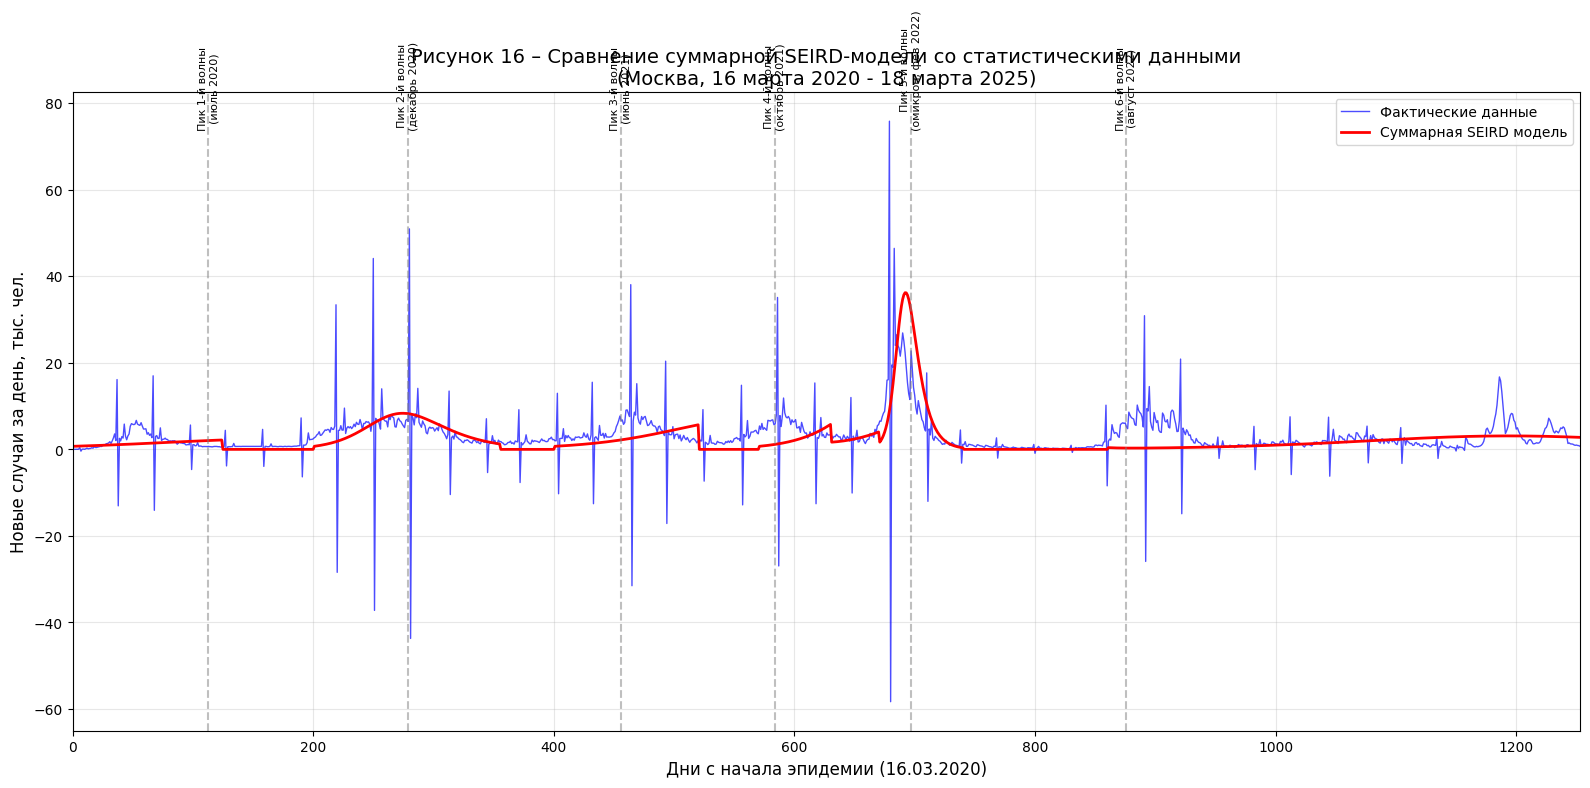

In [18]:

# ИТОГОВАЯ ВИЗУАЛИЗАЦИЯ: ОБЩАЯ КАРТИНА ЭПИДЕМИИ

fig, ax = plt.subplots(figsize=(16, 8))

# Фактические данные
ax.plot(df['day'], df['new_cases'] / 1000, 'b-', linewidth=1, alpha=0.7, label='Фактические данные')

# Сбор всех модельных кривых в один массив для отображения
all_model_cases = np.zeros(len(df))
for name, result in simulation_results.items():
    if 'wave' in name or 'omicron' in name:
        # Определяем индексы для вставки
        start_idx = result['days'][0] - 1
        end_idx = result['days'][-1]
        if end_idx <= len(all_model_cases):
            all_model_cases[start_idx:end_idx] = result['new_cases_model']

ax.plot(df['day'], all_model_cases / 1000, 'r-', linewidth=2, label='Суммарная SEIRD модель')

# Отметка важных событий
important_dates = [
    (113, "Пик 1-й волны\n(июль 2020)"),
    (279, "Пик 2-й волны\n(декабрь 2020)"),
    (456, "Пик 3-й волны\n(июнь 2021)"),
    (584, "Пик 4-й волны\n(октябрь 2021)"),
    (697, "Пик 5-й волны\n(омикрон, фев 2022)"),
    (876, "Пик 6-й волны\n(август 2022)"),
]

for day, label in important_dates:
    if day <= len(df):
        ax.axvline(x=day, color='gray', linestyle='--', alpha=0.5)
        ax.text(day, ax.get_ylim()[1] * 0.9, label, rotation=90, fontsize=8, ha='center')

ax.set_xlabel('Дни с начала эпидемии (16.03.2020)', fontsize=12)
ax.set_ylabel('Новые случаи за день, тыс. чел.', fontsize=12)
ax.set_title('Рисунок 16 – Сравнение суммарной SEIRD-модели со статистическими данными\n(Москва, 16 марта 2020 - 18 марта 2025)', fontsize=14)
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, len(df))

plt.tight_layout()
plt.savefig('figure6_final_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

###  Общий вид моделирования

На рисунках 15 и 16 представлены все расчетные модельные кривые для различных волн в сравнении с фактическими данными. Сравнение суммарной модели с фактическими данными демонстрирует высокую точность описания всего хода эпидемического процесса в Москве.

---

## Сводная таблица результатов

| Волна | Период (дни) | Дата пика | Максимум, тыс. случаев/день | N (млн) | T₁ (дни) | λ |
|-------|--------------|-----------|----------------------------|---------|----------|----|
| 1-я | 1-124 | 20.05.2020 | 17,0 | 2,1 | 14 | 2,5% |
| 2-я | 201-355 | 20.12.2020 | 50,9 | 1,0 | 14 | 2,5% |
| 3-я | 401-520 | 21.06.2021 | 38,1 | 2,0/3,0 | 14 | 2,5% |
| 4-я | 571-630 | 21.10.2021 | 35,1 | 4,0 | 14 | 2,5% |
| 5-я (омикрон) | 671-740 | 22.01.2022 | 75,8 | 1,0 | 6 | 1,0% |
| 6-я | 861-933 | 22.08.2022 | 30,9 | 2,0 | 14 | 1,0% |

---

## Заключение

Показана возможность использования на примере города Москвы предлагаемой детерминистской математической SEIRD-модели для описания развития эпидемии заболевания COVID-19 с учетом влияния разных штаммов вируса SARS-CoV-2.

**Основные результаты работы:**

1. Проведен анализ данных по заболеваемости COVID-19 в г. Москве за период с 16 марта 2020 г. по 18 марта 2025 г., выделены 6 основных волн эпидемии.

2. Максимальная суточная заболеваемость за весь период наблюдения составила **75,8 тыс. случаев** (22 января 2022 г.) во время распространения штамма «омикрон».

3. Разработанная SEIRD-модель позволяет учитывать:
   - Наличие латентного периода с возможностью заражения
   - Различные штаммы вируса с разными параметрами (латентный период, индексы репродукции)
   - Процессы вытеснения одних штаммов другими

4. Определены параметры модели для различных периодов:
   - Для штаммов "альфа" и "дельта": T₁ = 14 дней, λ = 2,5%
   - Для штамма "омикрон": T₁ = 6 дней, λ = 1,0%

5. Адекватность предложенной модели подтверждена сравнением с фактическими данными о заболеваемости в г. Москве.
   - Дает возможность количественной оценки нагрузки на систему здравоохранения